Clustering methods basically consists of grouping points of data with similar features. These groups are called clusters. One of the simplest clustering methods is the k-means. In this case, we are given a dataset of points in a plane, and we want to group them into k clusters. To do so, in the most basic form of the algorithm, a set of k points called centroids are randomly sampled, and we form the first set of clusters by assigning each point to its nearest centroid. Then, for every cluster, we compute the mean of its points, and set this as the new centroid. Again, we assign each data point to its nearest centroid, and update the centroids by computing the clusters' means. The expectation-maximization procedure is repeated until centroids remain unchanged up to certain tolerance.

https://realpython.com/k-means-clustering-python/

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()  # for plot styling
import numpy as np

from sklearn.metrics import pairwise_distances_argmin
from sklearn.cluster import KMeans, SpectralClustering, MiniBatchKMeans
from sklearn.datasets import make_blobs, make_moons

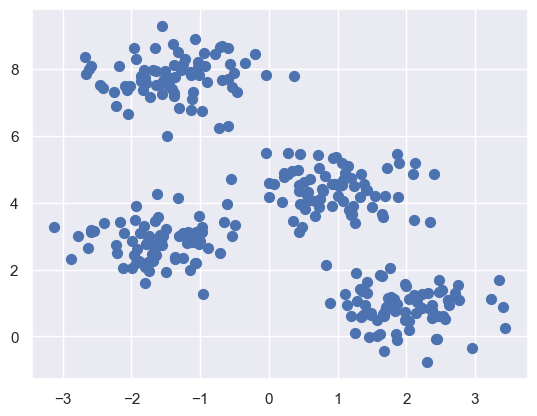

In [17]:
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.show()

Perform the k-means fitting.

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


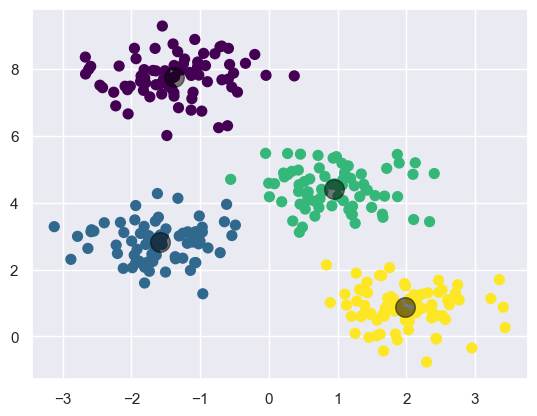

In [8]:
good_init = np.array([[-3, 8], [-1, 2], [1, 3], [2, 0]])
kmeans = KMeans(n_clusters=4, init=good_init, n_init=1)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)


plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
plt.show()

It is important to mention that this methods has an important caveat: the result depends on the initial guess for the centroids positions, and unlucky guesses can lead to poor clustering due to convergence to a local optimum. This can be addressed by two different ways: providing oneself the initial guess if clusters are more of less easy to locate by eye; or running accross many initial guesses and choosing the one with smaller mean-squared-distance. By default, KMeans() runs over 10 initial guesses.

In [9]:
kmeans.score(X)

-212.0059962108348

KMeans is limited to produce clusters with linear boundaries. Therefore, clusters with highly non-linear boundaries require a different kind of approach. As well as there is a variant of support vector machine for non-linear kernels, there is also a non-linear version of KMeans, called SpectralClustering. This uses a graph of nearest neighbors to compute a higher representation of the datapoints and a k-means fitting is implemented in such space.

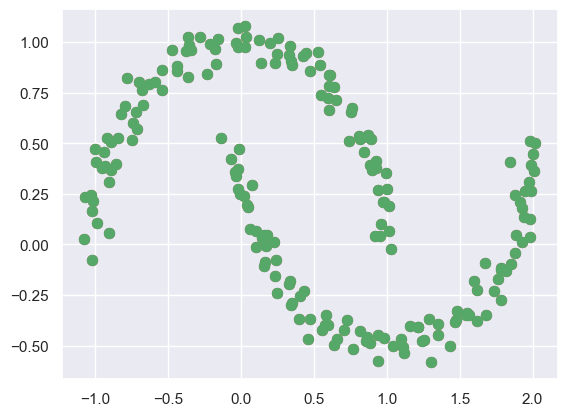

In [13]:
X, y = make_moons(200, noise=.05, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.show()

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


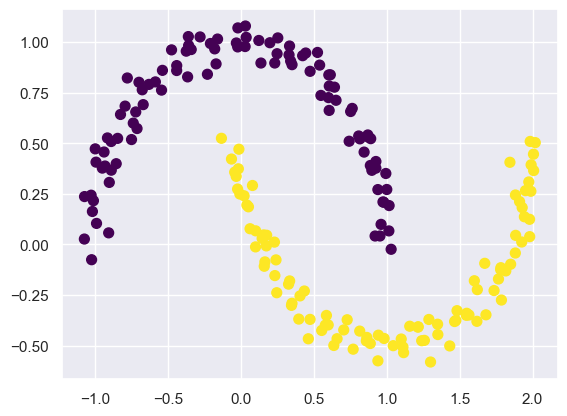

In [15]:
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                           assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis');
plt.show()

On the other hand, since the algorithm in its basic form requires to perform evaluations through the whole dataset, applying this to large amounts of data can become highly expensive. To overcome this, a variant called Mini-Batch KMeans was developed. It basically consists of taking batches of data to update the centroids just slightly at each iteration.

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1952: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 6144 or by setting the environment variable OMP_NUM_THREADS=2
  warnings.warn(


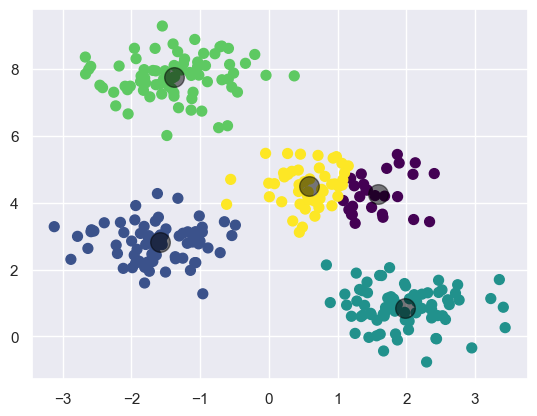

In [18]:
minibatch_kmeans = MiniBatchKMeans(n_clusters=5)
minibatch_kmeans.fit(X)

y_kmeans = minibatch_kmeans.predict(X)


plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = minibatch_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
plt.show()